In [2]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time
from sklearn.linear_model import Ridge, Lasso

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..',)))
from lib.utils.reservoirpy import (
    fit_scaler, transform_array, inverse_transform_array
)

np.random.seed(42)

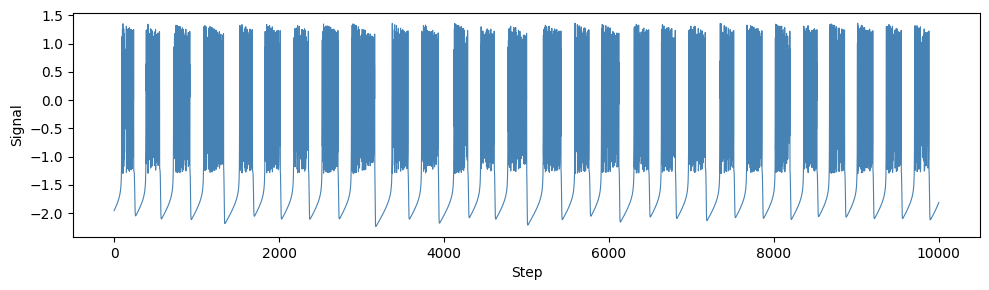

Total combinations to evaluate: 486
[10/486]  elapsed: 7s  ETA: 325s  current best NRMSE: 1.358624
[20/486]  elapsed: 14s  ETA: 318s  current best NRMSE: 1.161131
[30/486]  elapsed: 21s  ETA: 319s  current best NRMSE: 1.161131
[40/486]  elapsed: 28s  ETA: 312s  current best NRMSE: 1.161131
[50/486]  elapsed: 35s  ETA: 308s  current best NRMSE: 1.161131
[60/486]  elapsed: 43s  ETA: 303s  current best NRMSE: 1.161131
[70/486]  elapsed: 50s  ETA: 298s  current best NRMSE: 1.161131
[80/486]  elapsed: 57s  ETA: 292s  current best NRMSE: 1.147621
[90/486]  elapsed: 68s  ETA: 301s  current best NRMSE: 1.147621
[100/486]  elapsed: 79s  ETA: 306s  current best NRMSE: 1.147621
[110/486]  elapsed: 90s  ETA: 307s  current best NRMSE: 1.147621
[120/486]  elapsed: 101s  ETA: 307s  current best NRMSE: 1.147621
[130/486]  elapsed: 111s  ETA: 305s  current best NRMSE: 1.147621
[140/486]  elapsed: 122s  ETA: 303s  current best NRMSE: 1.147621
[150/486]  elapsed: 133s  ETA: 298s  current best NRMSE: 1.14

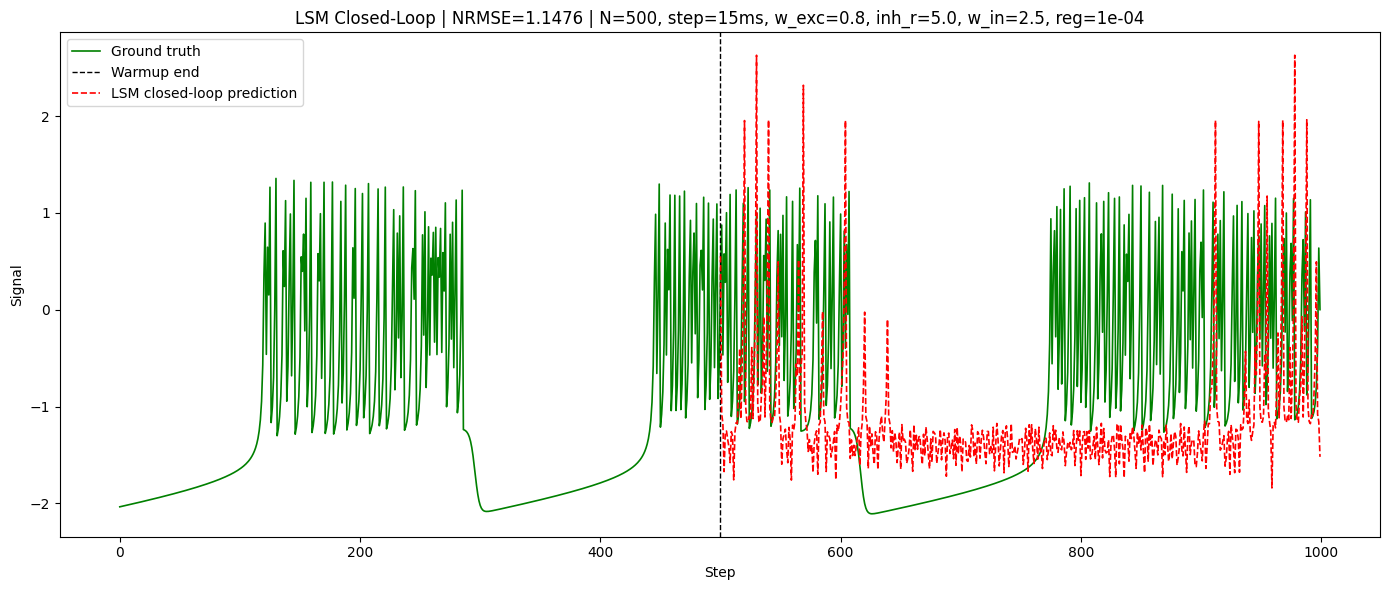

In [3]:
# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../../../data/chaotic_data/rulkov_map.csv', delimiter=',')
dataset = dataset[:, 0]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset, color='steelblue', linewidth=0.8)
ax.set_xlabel('Step'); ax.set_ylabel('Signal')
plt.tight_layout(); plt.show()


# ==========================================================
# DATA PREPARATION
# ==========================================================
data = dataset.reshape(-1, 1)
X_raw = data[:-1]
Y_raw = data[1:]


# ==========================================================
# FIXED SETTINGS
# ==========================================================
train_len        = 4000
test_start       = 4000
test_len         = 1000
regression_model = "ridge"
seed             = 42

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]
X_test_raw  = X_raw[test_start:test_start + test_len]
Y_test_raw  = Y_raw[test_start:test_start + test_len]


# ==========================================================
# LIF RESERVOIR — PURE NUMPY
# ==========================================================
# All units in milliseconds and millivolts (dimensionless internally).
# This avoids any unit-handling overhead.

class LIFReservoir:
    """
    A Liquid State Machine reservoir using Leaky Integrate-and-Fire neurons.
    Entirely in NumPy — no Brian2, no compilation, no overhead.

    Internal units: mV for voltages, ms for time.
    """

    def __init__(
        self,
        N_liquid,
        N_input,
        tau_mem,           # ms
        tau_syn,           # ms
        dt,                # ms — integration timestep
        step_duration,     # ms — how long one input sample is presented
        V_rest=-65.0,
        V_reset=-65.0,
        V_thresh=-50.0,
        refrac_steps=2,    # refractory period in units of dt
        exc_frac=0.8,
        conn_prob=0.1,
        input_conn_prob=0.3,
        w_exc=0.5,         # mV
        w_inh=-2.0,        # mV
        w_input=1.0,       # mV
        encoding="population",
        sigma_enc=0.2,
        rng_seed=42,
    ):
        self.N         = N_liquid
        self.N_input   = N_input
        self.tau_mem   = tau_mem
        self.tau_syn   = tau_syn
        self.dt        = dt
        self.step_dur  = step_duration
        self.V_rest    = V_rest
        self.V_reset   = V_reset
        self.V_thresh  = V_thresh
        self.refrac_steps = refrac_steps
        self.encoding  = encoding
        self.sigma_enc = sigma_enc

        # How many integration substeps per input sample
        self.n_substeps = int(round(step_duration / dt))

        # Precompute decay constants
        self.decay_mem = np.exp(-dt / tau_mem)
        self.drive_scale = (1.0 - self.decay_mem)   # for Euler: dt/tau_mem factor
        self.decay_syn = np.exp(-dt / tau_syn)
        # Decay for the exponential spike-count filter (per input step)
        self.decay_filt = np.exp(-step_duration / tau_syn)

        rng = np.random.RandomState(rng_seed)

        # ---- Build weight matrices ----
        n_exc = int(exc_frac * N_liquid)

        # Recurrent weights: sparse random, Dale's law
        W_rec = np.zeros((N_liquid, N_liquid), dtype=np.float32)
        mask  = rng.rand(N_liquid, N_liquid) < conn_prob
        np.fill_diagonal(mask, False)          # no self-connections
        W_rec[mask] = w_exc                    # default excitatory
        # Inhibitory presynaptic neurons overwrite their outgoing weights
        inh_rows = np.arange(n_exc, N_liquid)
        W_rec[:, inh_rows] = np.where(
            mask[:, inh_rows], w_inh, 0.0
        )
        self.W_rec = W_rec   # shape (N_liquid, N_liquid): W_rec[post, pre]

        # Input weights: sparse random
        W_in_mask = rng.rand(N_liquid, N_input) < input_conn_prob
        self.W_in = np.where(W_in_mask, w_input, 0.0).astype(np.float32)

        # Population encoding centers
        self.mu = np.linspace(-1.0, 1.0, N_input)

        # ---- State variables ----
        self.reset_state()

    def reset_state(self):
        """Reset all dynamic variables to resting state."""
        self.V      = np.full(self.N, self.V_rest, dtype=np.float64)
        self.I_syn  = np.zeros(self.N, dtype=np.float64)
        self.refrac = np.zeros(self.N, dtype=np.int32)   # remaining refractory steps
        self.filt   = np.zeros(self.N, dtype=np.float64)  # exponential spike filter

    def _encode(self, x_scalar):
        """Convert scalar input to input-neuron spike rates / currents."""
        if self.encoding == "direct":
            return np.full(self.N_input, float(x_scalar))
        else:  # population
            return np.exp(
                -((self.mu - float(x_scalar)) ** 2) / (2 * self.sigma_enc ** 2)
            )

    def _step_one_sample(self, x_scalar):
        """
        Present one input sample for step_duration ms.
        Returns the spike count per neuron during this window.
        """
        # Encode input -> input-neuron activations
        inp_act = self._encode(x_scalar)          # (N_input,)
        I_input = self.W_in @ inp_act             # (N_liquid,)  — static for this sample

        spike_counts = np.zeros(self.N, dtype=np.float64)

        for _ in range(self.n_substeps):
            # Neurons not in refractory period update their voltage
            active = self.refrac <= 0

            # Exponential Euler for V:
            #   V(t+dt) = V_rest + (V(t) - V_rest) * exp(-dt/tau)
            #           + (I_syn + I_input) * (1 - exp(-dt/tau))
            self.V[active] = (
                self.V_rest
                + (self.V[active] - self.V_rest) * self.decay_mem
                + (self.I_syn[active] + I_input[active]) * self.drive_scale
            )

            # Synaptic current decays each substep
            self.I_syn *= self.decay_syn

            # Decrement refractory counters
            self.refrac[~active] -= 1

            # Threshold crossing -> spike
            spiked = self.V >= self.V_thresh
            if np.any(spiked):
                spike_counts[spiked] += 1.0
                self.V[spiked]      = self.V_reset
                self.refrac[spiked] = self.refrac_steps
                # Deliver spikes to postsynaptic neurons via W_rec
                # W_rec[post, pre], so sum over spiked pre neurons
                self.I_syn += self.W_rec[:, spiked].sum(axis=1)

        return spike_counts

    def run_sequence(self, input_sequence):
        """
        Drive the reservoir with a sequence of scalar inputs.
        Returns the liquid state matrix: (T, N_liquid).
        """
        T = len(input_sequence)
        states = np.zeros((T, self.N), dtype=np.float64)

        for t in range(T):
            counts = self._step_one_sample(input_sequence[t, 0])
            # Exponential filter on spike counts -> liquid state
            self.filt = self.filt * self.decay_filt + counts
            states[t] = self.filt

        return states

    def run_one_step(self, x_scalar):
        """
        Present one scalar, advance the liquid, update filter, return state.
        Used in closed-loop rollout.
        """
        counts    = self._step_one_sample(x_scalar)
        self.filt = self.filt * self.decay_filt + counts
        return self.filt.copy()


# ==========================================================
# PARAMETER GRID
# ==========================================================
param_grid = {
    "normalization":     ["minmax11"],
    "train_warmup":      [200],
    "test_warmup":       [500],
    "N_liquid":          [500, 1000],

    # Tier 1
    "step_duration":     [15, 25, 40],
    "w_exc":             [0.3, 0.5, 0.8],
    "inh_ratio":         [3.0, 4.0, 5.0],
    "w_input":           [0.8, 1.5, 2.5],
    "regression":        [1e-6, 1e-5, 1e-4],

    # Tier 2/3 fixed
    "tau_mem":           [30],
    "tau_syn":           [5],
    "encoding":          ["population"],
}

keys   = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[k] for k in keys]))
print(f"Total combinations to evaluate: {len(combos)}")


# ==========================================================
# EVALUATION FUNCTION
# ==========================================================
def evaluate_lsm(
    normalization, train_warmup, test_warmup,
    N_liquid, step_duration, w_exc, inh_ratio, w_input, regression,
    tau_mem, tau_syn, encoding, rng_seed=42,
):
    try:
        if test_warmup >= test_len:
            return np.inf

        scaler  = fit_scaler(X_train_raw, method=normalization)
        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test  = transform_array(X_test_raw,  scaler)
        Y_test  = transform_array(Y_test_raw,  scaler)

        pred_len      = test_len - test_warmup
        Y_true_scaled = Y_test[test_warmup:test_warmup + pred_len, 0]

        if train_warmup >= len(X_train):
            return np.inf

        # Build reservoir
        lsm = LIFReservoir(
            N_liquid=N_liquid,
            N_input=50,
            tau_mem=tau_mem,
            tau_syn=tau_syn,
            dt=1.0,
            step_duration=step_duration,
            w_exc=w_exc,
            w_inh=-inh_ratio * w_exc,
            w_input=w_input,
            encoding=encoding,
            rng_seed=rng_seed,
        )

        # --- Training ---
        S_train = lsm.run_sequence(X_train)

        # Health check
        mean_rate = S_train.mean()
        if mean_rate < 1e-3 or mean_rate > 1e4 or not np.isfinite(mean_rate):
            return np.inf

        S_train_fit = S_train[train_warmup:]
        Y_train_fit = Y_train[train_warmup:, 0]

        if regression_model == "ridge":
            readout = Ridge(alpha=regression)
        else:
            readout = Lasso(alpha=regression, max_iter=10000)
        readout.fit(S_train_fit, Y_train_fit)

        # --- Sync on true test data ---
        lsm.reset_state()
        lsm.run_sequence(X_test[:test_warmup])

        # --- Closed-loop rollout ---
        Y_pred_scaled = np.zeros(pred_len)
        current_input = float(X_test[test_warmup, 0])

        for k in range(pred_len):
            state = lsm.run_one_step(current_input)
            pred  = readout.predict(state.reshape(1, -1))[0]
            if not np.isfinite(pred) or abs(pred) > 1e6:
                return np.inf
            Y_pred_scaled[k] = pred
            current_input = pred

        rmse  = np.sqrt(np.mean((Y_true_scaled - Y_pred_scaled) ** 2))
        denom = np.std(Y_true_scaled)
        if denom == 0:
            return np.inf
        return rmse / denom

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf


# ==========================================================
# RUN GRID SEARCH
# ==========================================================
results     = []
best_nrmse  = np.inf
best_params = None
t_start     = time.time()

for trial_idx, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse  = evaluate_lsm(**params, rng_seed=seed)
    results.append({**params, "nrmse": nrmse})

    if nrmse < best_nrmse:
        best_nrmse  = nrmse
        best_params = params.copy()

    if (trial_idx + 1) % 10 == 0 or (trial_idx + 1) == len(combos):
        elapsed = time.time() - t_start
        eta     = elapsed / (trial_idx + 1) * (len(combos) - (trial_idx + 1))
        print(
            f"[{trial_idx+1}/{len(combos)}]  "
            f"elapsed: {elapsed:.0f}s  ETA: {eta:.0f}s  "
            f"current best NRMSE: {best_nrmse:.6f}"
        )

total_time = time.time() - t_start


# ==========================================================
# RESULTS
# ==========================================================
print("\n" + "=" * 80)
print("LSM GRID SEARCH COMPLETE (NumPy LIF)")
print(f"Train interval      : [0 : {train_len}]")
print(f"Test interval       : [{test_start} : {test_start + test_len}]")
print(f"Total time          : {total_time:.1f}s ({total_time/len(combos):.2f}s per trial)")
print(f"Regression model    : {regression_model}")
print(f"Best NRMSE          : {best_nrmse:.6f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:24s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["nrmse"])

print("\nTop 10 configurations:")
print(
    f"{'Rank':>4}  {'N':>5}  {'step':>5}  {'w_exc':>6}  {'inh_r':>5}  "
    f"{'w_in':>5}  {'tau_m':>5}  {'reg':>8}  {'NRMSE':>10}"
)
print("-" * 80)
for rank, r in enumerate(results_sorted[:10], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['N_liquid']):5d}  "
        f"{r['step_duration']:5.1f}  "
        f"{r['w_exc']:6.2f}  "
        f"{r['inh_ratio']:5.1f}  "
        f"{r['w_input']:5.2f}  "
        f"{r['tau_mem']:5.1f}  "
        f"{r['regression']:8.1e}  "
        f"{r['nrmse']:10.6f}"
    )


# ==========================================================
# REBUILD BEST MODEL & PLOT
# ==========================================================
bp = best_params
best_scaler = fit_scaler(X_train_raw, method=bp["normalization"])
X_train_b   = transform_array(X_train_raw, best_scaler)
Y_train_b   = transform_array(Y_train_raw, best_scaler)
X_test_b    = transform_array(X_test_raw,  best_scaler)
Y_test_b    = transform_array(Y_test_raw,  best_scaler)

lsm = LIFReservoir(
    N_liquid=bp["N_liquid"],
    N_input=50,
    tau_mem=bp["tau_mem"],
    tau_syn=bp["tau_syn"],
    dt=1.0,
    step_duration=bp["step_duration"],
    w_exc=bp["w_exc"],
    w_inh=-bp["inh_ratio"] * bp["w_exc"],
    w_input=bp["w_input"],
    encoding=bp["encoding"],
    rng_seed=seed,
)

# Train
S_train = lsm.run_sequence(X_train_b)
S_train_fit = S_train[bp["train_warmup"]:]
Y_train_fit = Y_train_b[bp["train_warmup"]:, 0]

if regression_model == "ridge":
    readout = Ridge(alpha=bp["regression"])
else:
    readout = Lasso(alpha=bp["regression"], max_iter=10000)
readout.fit(S_train_fit, Y_train_fit)

# Sync + closed-loop
lsm.reset_state()
lsm.run_sequence(X_test_b[:bp["test_warmup"]])

pred_len = test_len - bp["test_warmup"]
Y_pred_scaled = np.zeros(pred_len)
current_input = float(X_test_b[bp["test_warmup"], 0])

for k in range(pred_len):
    state = lsm.run_one_step(current_input)
    pred  = readout.predict(state.reshape(1, -1))[0]
    Y_pred_scaled[k] = pred
    current_input = pred

Y_pred_b = inverse_transform_array(
    Y_pred_scaled.reshape(-1, 1), best_scaler
).ravel()
Y_true_b = inverse_transform_array(
    Y_test_b[bp["test_warmup"]:bp["test_warmup"] + pred_len], best_scaler
).ravel()

mse   = np.mean((Y_true_b - Y_pred_b) ** 2)
rmse  = np.sqrt(mse)
nrmse = rmse / np.std(Y_true_b)

print(f"\nFinal best-model metrics (original scale):")
print(f"MSE   : {mse:.10f}")
print(f"RMSE  : {rmse:.10f}")
print(f"NRMSE : {nrmse:.10f}")

# --- Diagnostic: average spike rate ---
print(f"Avg filtered spike count (training): {S_train.mean():.4f}")

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(np.arange(test_len), Y_test_raw[:, 0], c="green",
        label="Ground truth", linewidth=1.2)
ax.axvline(bp["test_warmup"], ls="--", c="k", lw=1.0, label="Warmup end")
ax.plot(np.arange(bp["test_warmup"], bp["test_warmup"] + pred_len),
        Y_pred_b, ls="--", c="red", label="LSM closed-loop prediction", lw=1.2)
ax.set_title(
    f"LSM Closed-Loop | NRMSE={nrmse:.4f} | "
    f"N={bp['N_liquid']}, step={bp['step_duration']}ms, "
    f"w_exc={bp['w_exc']}, inh_r={bp['inh_ratio']}, "
    f"w_in={bp['w_input']}, reg={bp['regression']:.0e}"
)
ax.set_xlabel("Step"); ax.set_ylabel("Signal")
ax.legend(); plt.tight_layout(); plt.show()